In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/robiulhasanjisan/university-student-performance-and-habits-dataset/Student_data.csv


,Student_ID,Gender,Age,Major,Attendance_Pct,Study_Hours_Per_Day,Previous_GPA,Sleep_Hours,Social_Hours_Week,Final_CGPA
0,ID00001,Male,20,Engineering,83.9,4.4,2.65,9.1,8,2.78
1,ID00002,Female,24,Business,80.7,4.0,3.58,4.0,4,3.76
2,ID00003,Female,20,Mathematics,91.5,3.9,3.29,6.7,4,3.75
3,ID00004,Female,23,Engineering,73.9,8.8,3.48,4.0,6,3.69
4,ID00005,Male,21,Economics,79.8,2.2,2.66,8.7,6,2.34


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Student_ID           5000 non-null   object 
 1   Gender               5000 non-null   object 
 2   Age                  5000 non-null   int64  
 3   Major                5000 non-null   object 
 4   Attendance_Pct       5000 non-null   float64
 5   Study_Hours_Per_Day  5000 non-null   float64
 6   Previous_GPA         5000 non-null   float64
 7   Sleep_Hours          5000 non-null   float64
 8   Social_Hours_Week    5000 non-null   int64  
 9   Final_CGPA           5000 non-null   float64
dtypes: float64(5), int64(2), object(3)
memory usage: 390.8+ KB
None

Բացակայող արժեքներ:
Student_ID             0
Gender                 0
Age                    0
Major                  0
Attendance_Pct         0
Study_Hours_Per_Day    0
Previous_GPA           0
Sleep_Hours            0
Soc

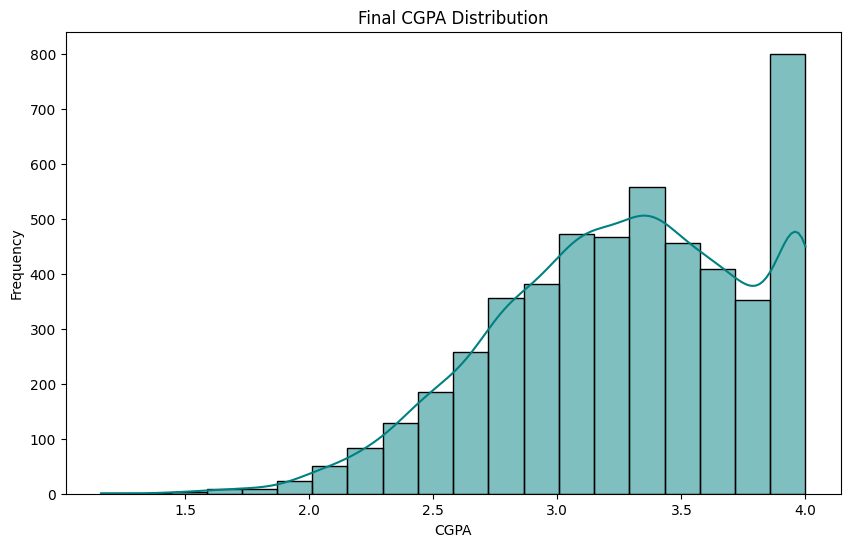

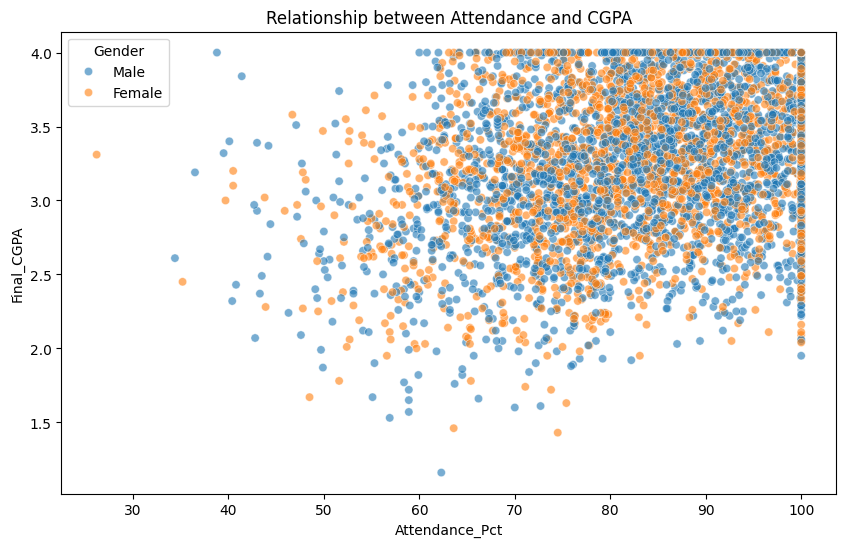

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import os


for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv'):
            path = os.path.join(dirname, filename)
            print(f"{path}")


df = pd.read_csv(path)


display(df.head())


print(df.info())
print("\nԲացակայող արժեքներ:")
print(df.isnull().sum())


plt.figure(figsize=(10, 6))


sns.histplot(df['Final_CGPA'], bins=20, kde=True, color='teal')
plt.title('Final CGPA Distribution')
plt.xlabel('CGPA')
plt.ylabel('Frequency')
plt.show()


plt.figure(figsize=(10, 6))
sns.scatterplot(x='Attendance_Pct', y='Final_CGPA', data=df, hue='Gender', alpha=0.6)
plt.title('Relationship between Attendance and CGPA')
plt.show()

--- Տվյալների առաջին 5 տողերը ---


,Student_ID,Gender,Age,Major,Attendance_Pct,Study_Hours_Per_Day,Previous_GPA,Sleep_Hours,Social_Hours_Week,Final_CGPA
0,ID00001,Male,20,Engineering,83.9,4.4,2.65,9.1,8,2.78
1,ID00002,Female,24,Business,80.7,4.0,3.58,4.0,4,3.76
2,ID00003,Female,20,Mathematics,91.5,3.9,3.29,6.7,4,3.75
3,ID00004,Female,23,Engineering,73.9,8.8,3.48,4.0,6,3.69
4,ID00005,Male,21,Economics,79.8,2.2,2.66,8.7,6,2.34



--- Սյունակների տիպերը ---
Student_ID              object
Gender                  object
Age                      int64
Major                   object
Attendance_Pct         float64
Study_Hours_Per_Day    float64
Previous_GPA           float64
Sleep_Hours            float64
Social_Hours_Week        int64
Final_CGPA             float64
dtype: object


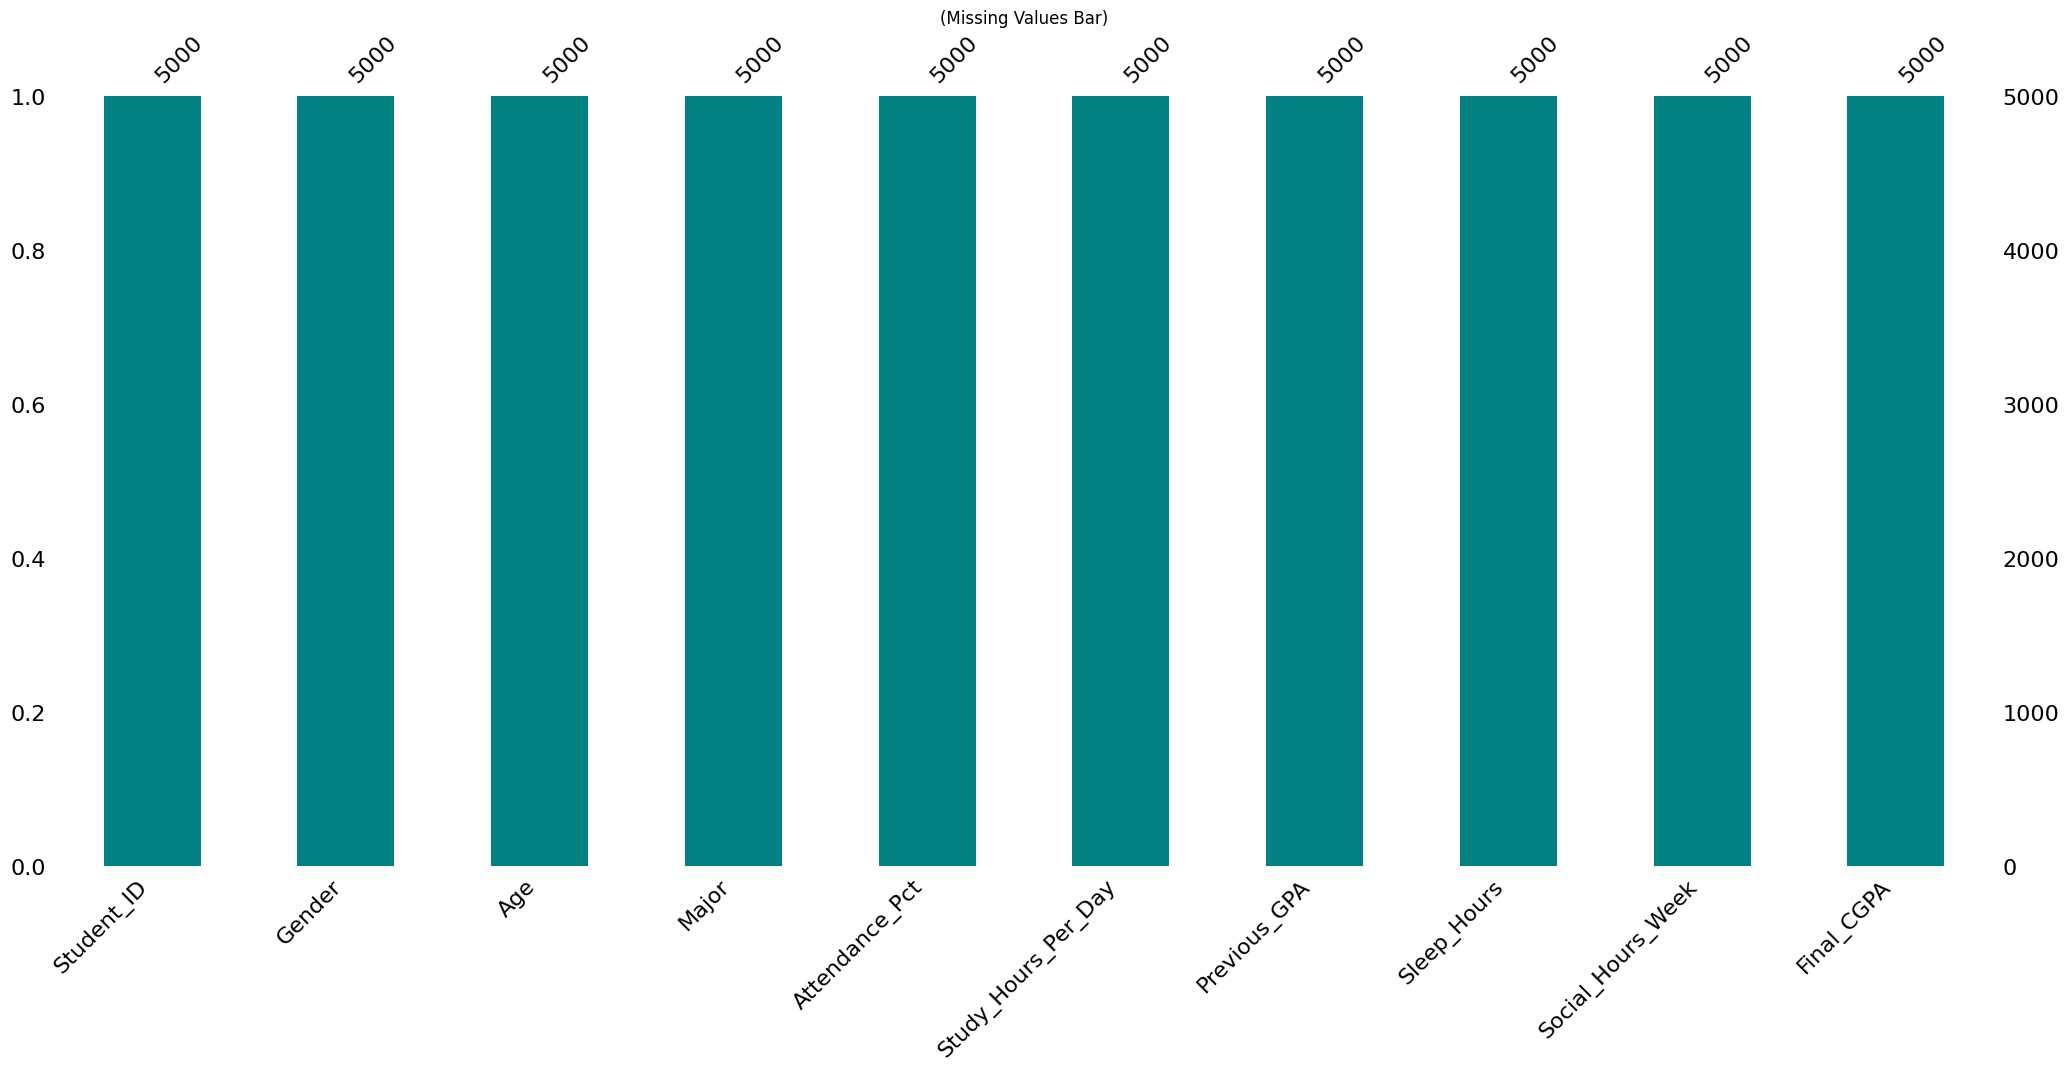

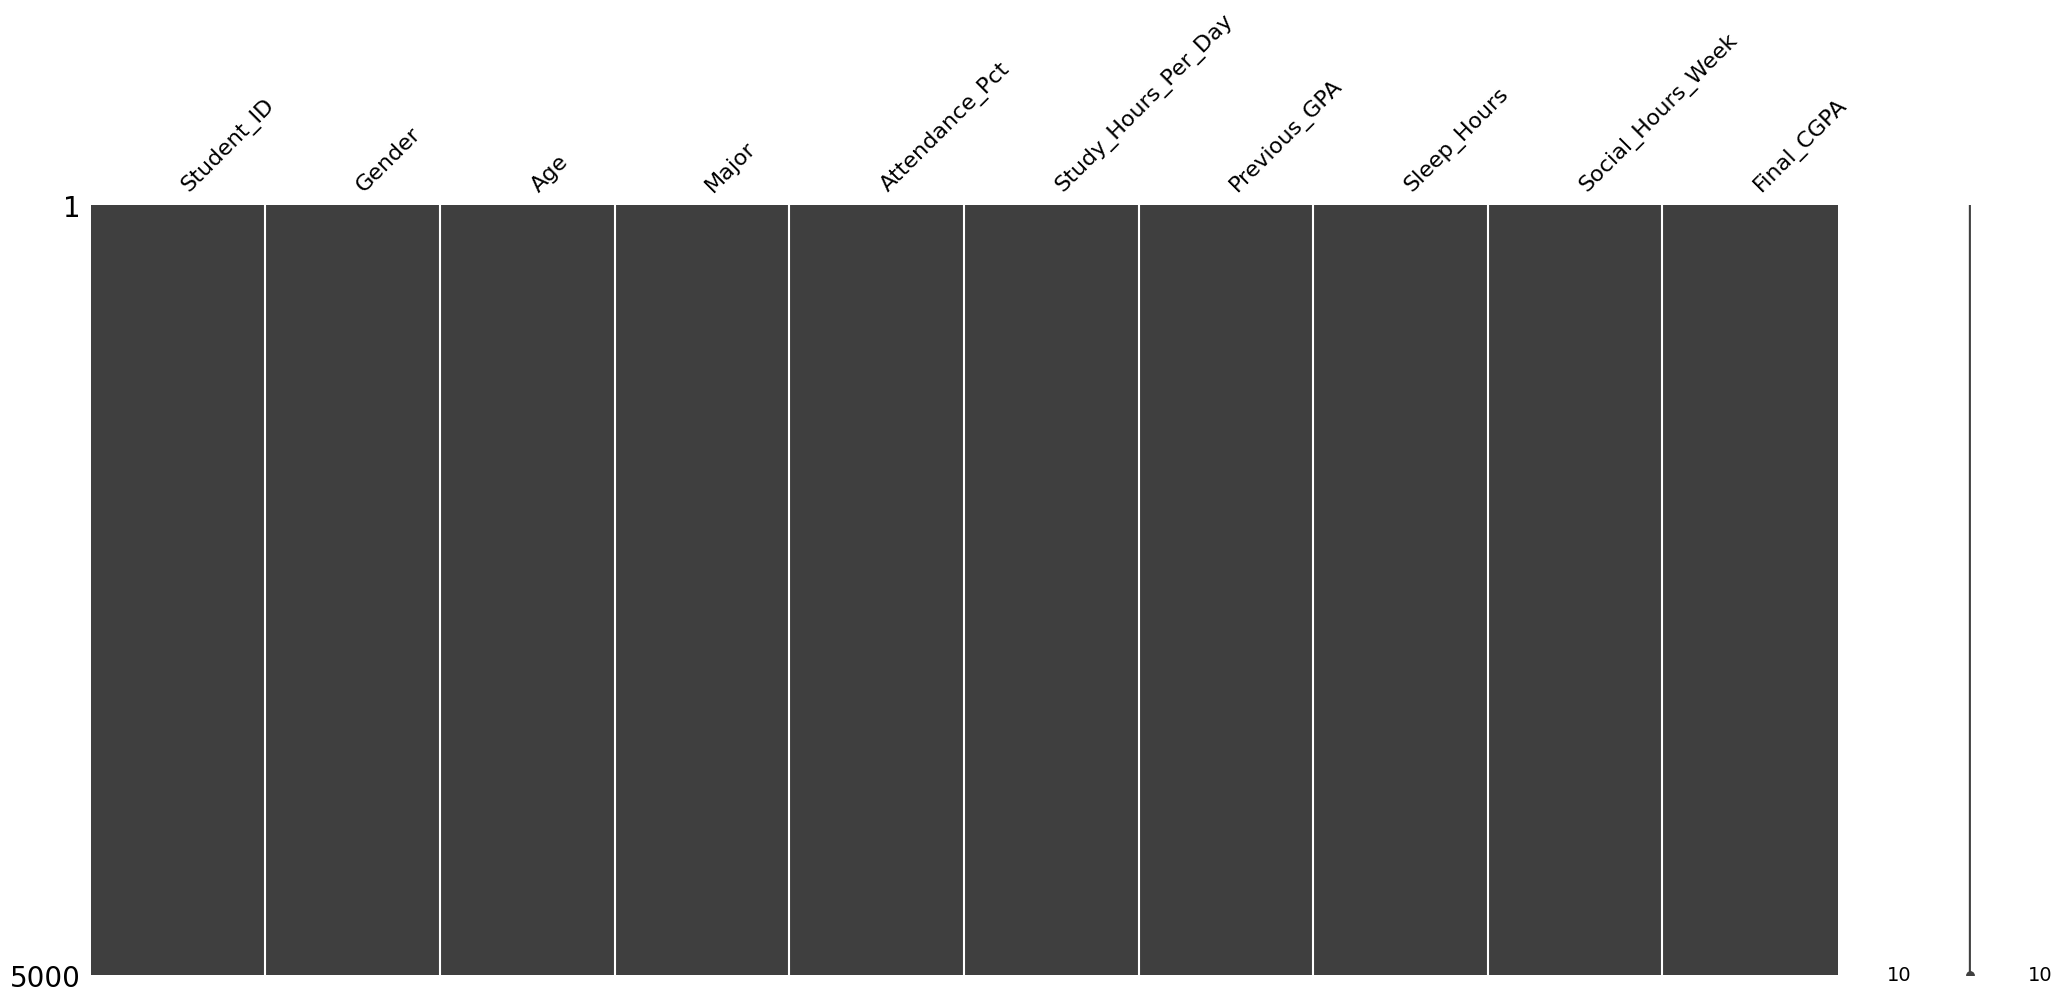

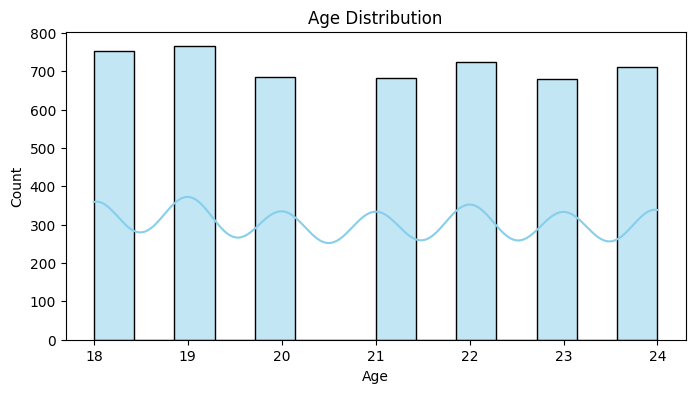

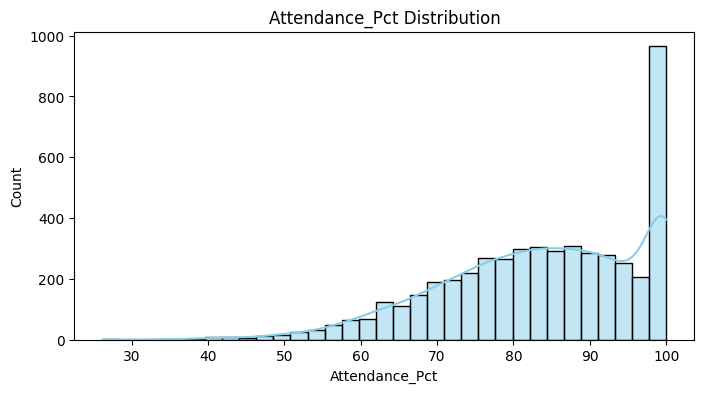

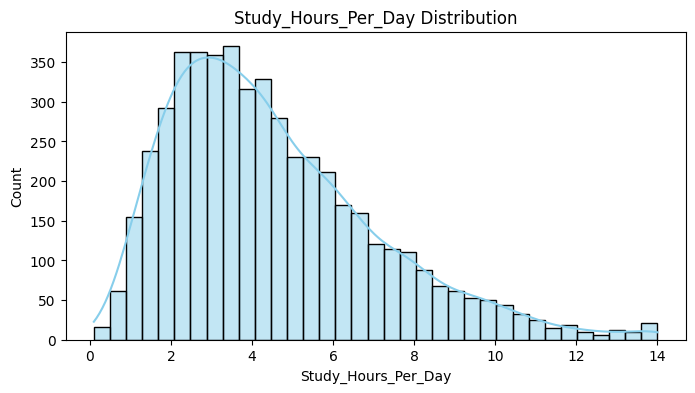

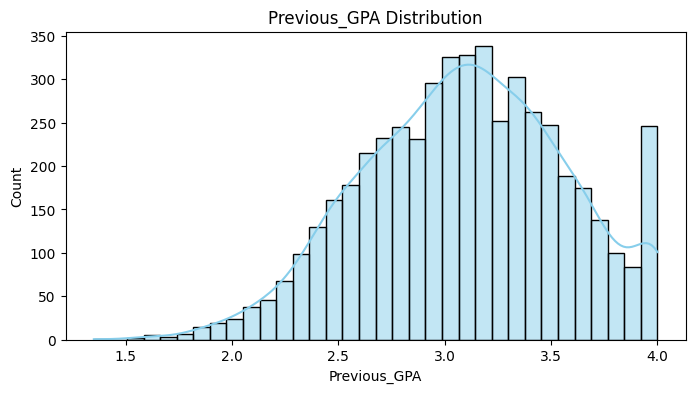

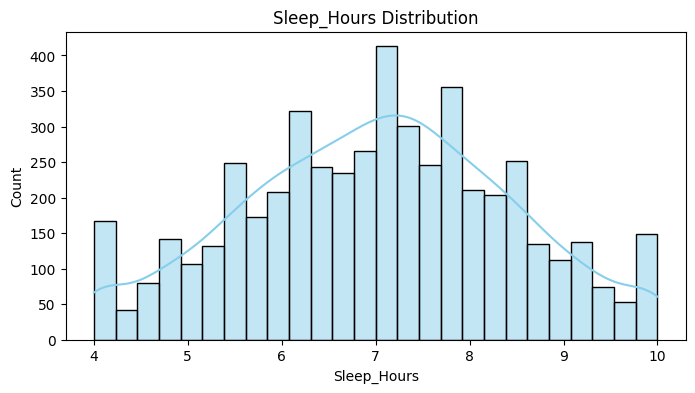

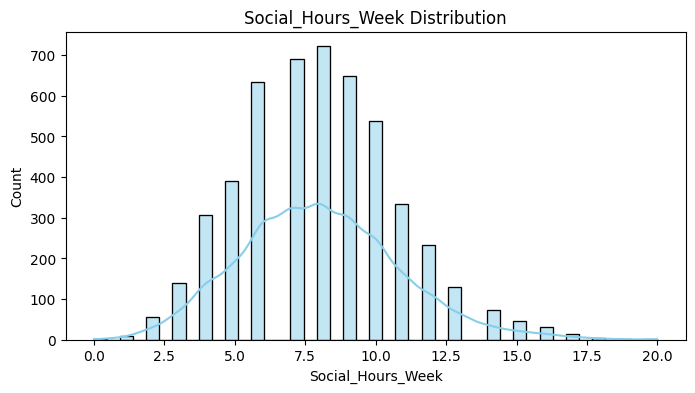

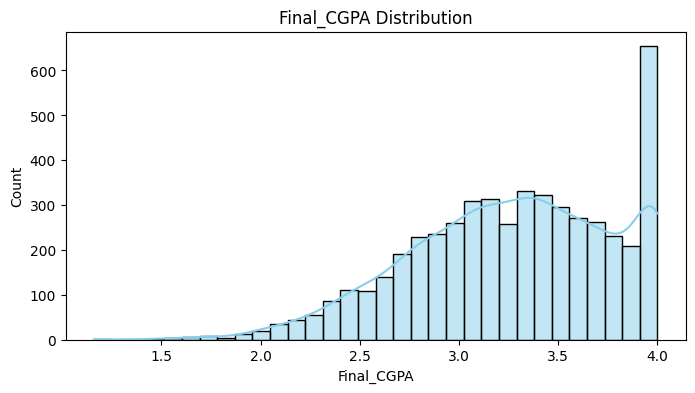

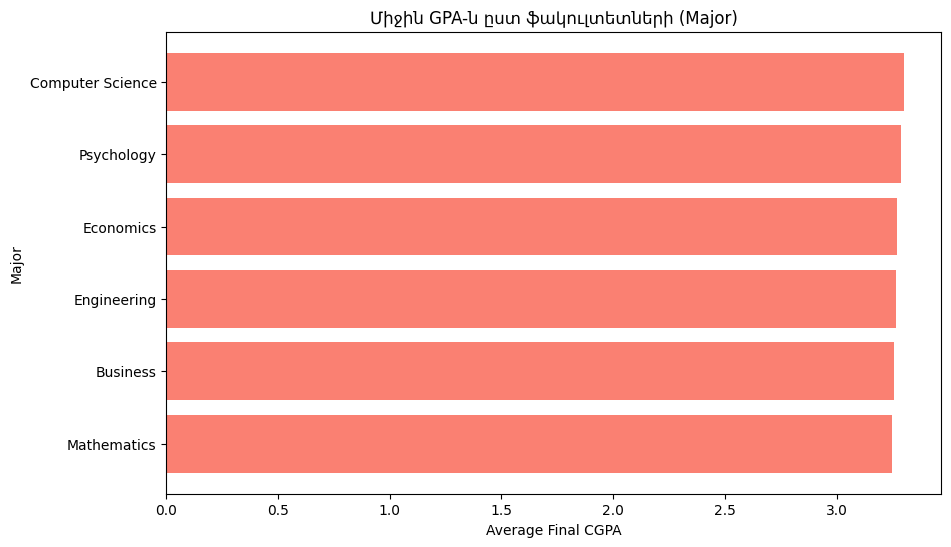

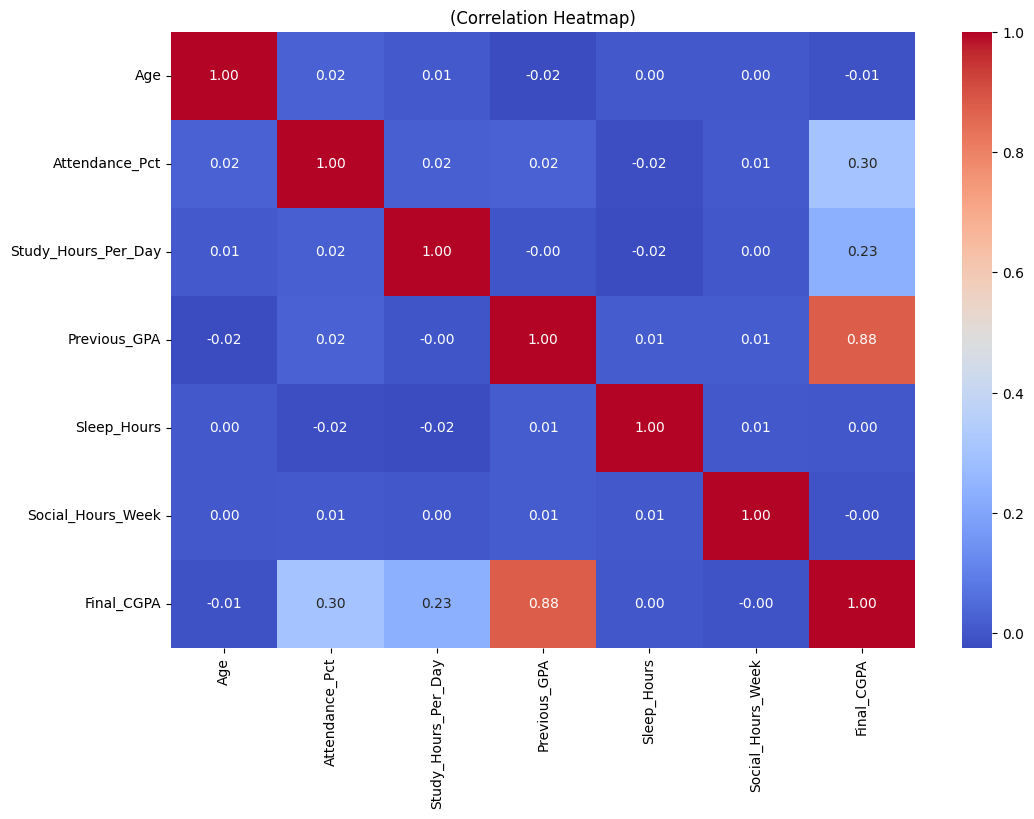

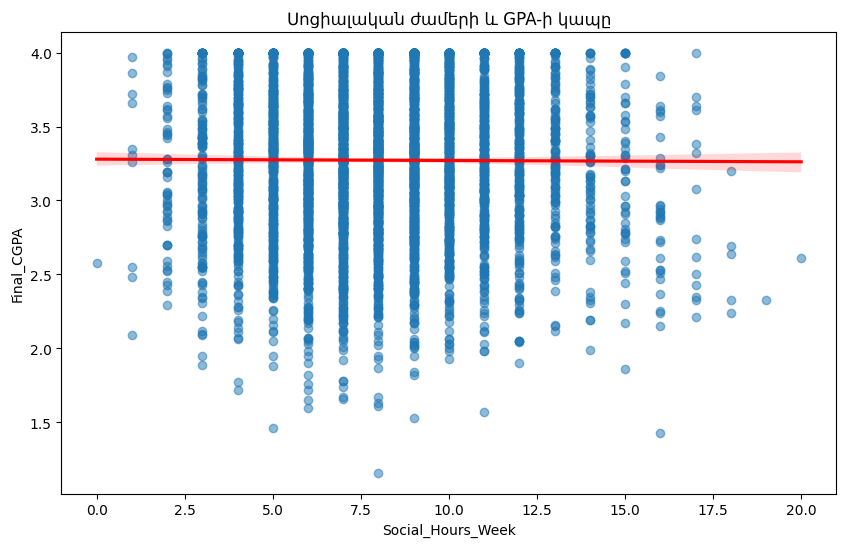

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import missingno as msno
import os


path = ""
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv'):
            path = os.path.join(dirname, filename)

df = pd.read_csv(path)


print("--- Տվյալների առաջին 5 տողերը ---")
display(df.head())

print("\n--- Սյունակների տիպերը ---")
print(df.dtypes)


plt.figure(figsize=(10, 4))
msno.bar(df, color="teal")
plt.title("(Missing Values Bar)")
plt.show()

msno.matrix(df)
plt.show()


num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'{col} Distribution')
    plt.show()

major_rating = df.groupby('Major')['Final_CGPA'].mean().sort_values(ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(major_rating.index, major_rating.values, color='salmon')
plt.title('Միջին GPA-ն ըստ ֆակուլտետների (Major)')
plt.xlabel('Average Final CGPA')
plt.ylabel('Major')
plt.show()


plt.figure(figsize=(12, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('(Correlation Heatmap)')
plt.show()

plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Social_Hours_Week', y='Final_CGPA', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Սոցիալական ժամերի և GPA-ի կապը')
plt.show()